# Implement CNN on MNITST Dataset 

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [34]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [35]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

model = models.Sequential([

    # Input + First Convolution Block
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        padding='same',
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(
        pool_size=(2,2),
        strides=(2,2),
        padding='valid'
    ),

    layers.Dropout(0.25),

    # Second Convolution Block
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        strides=(1,1),
        padding='same',
        activation='relu'
    ),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        strides=(1,1),
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(
        pool_size=(2,2),
        strides=(2,2)
    ),

    layers.Dropout(0.25),

    # Flatten
    layers.Flatten(),

    # Dense Layer
    layers.Dense(
        units=128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(
        units=10,
        activation='softmax'
    )
])

In [36]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 125ms/step - accuracy: 0.7977 - loss: 0.6023 - val_accuracy: 0.9835 - val_loss: 0.0567
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.9716 - loss: 0.0992 - val_accuracy: 0.9872 - val_loss: 0.0422
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 121ms/step - accuracy: 0.9807 - loss: 0.0676 - val_accuracy: 0.9892 - val_loss: 0.0381
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 122ms/step - accuracy: 0.9842 - loss: 0.0534 - val_accuracy: 0.9880 - val_loss: 0.0510
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.9857 - loss: 0.0496 - val_accuracy: 0.9909 - val_loss: 0.0332


In [38]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9907 - loss: 0.0259
Test Accuracy: 0.9926999807357788


In [43]:
predictions = model.predict(x_test)

print("Predicted Digit:", predictions[4].argmax())
print("Actual Digit:", y_test[4])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Predicted Digit: 4
Actual Digit: 4


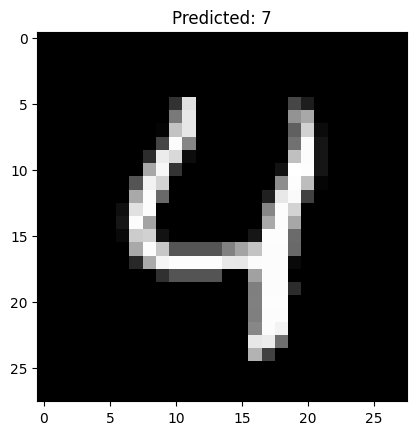

In [45]:
plt.imshow(x_test[4].reshape(28,28), cmap='gray')
plt.title("Predicted: " + str(predictions[0].argmax()))
plt.show()